# Regressão Logística nos dados covtype de LIBSVM

Iremos treinar os dados para classificação binária usando os dados `covtype` da biblioteca [LIBSVM](https://www.csie.ntu.edu.tw/~cjlin/libsvm/). Veja também [Kaggle-LIBSVM](https://www.kaggle.com/code/tanmayunhale/libsvm-liblinear).

Queremos minimizar

$$
\min_{w\in {\mathbb R}^{d\times1}} f(w)=-\frac{1}{n}\sum_{i=1}^n \left(y_i \log (s(x_i^\top w)) + (1 - y_i) \log (1 - s(x_i^\top w))\right) + \frac{\gamma}{2}\|w\|^2,
$$

onde $x_i\in {\mathbb R}^{d\times1}$, $y_i\in \{0, 1\}$, $s(z)=\frac{1}{1+\exp(-z)}$ é a função sigmóide. O gradiente é dado por

$$
\nabla f(w) = \frac{1}{n}\sum_{i=1}^n x_i(s(x_i^\top w)-y_i) + \gamma w.
$$

Esta é uma função suave com constante de Lipschitz $L=L_0+\gamma$ onde

$$
L_0 = \frac{1}{4}\lambda_{\max}\left(\frac{X^\top X}{n}\right),
$$ 

onde $X\in\mathbb{R}^{n\times d}$ é a matriz de dados cuja $i$-ézima linha é o vetor $x_i^\top$ e $\lambda_{\max}(\cdot)$ denota o maior autovalor.

In [82]:
# Importação de módulos necesserários:

import matplotlib
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la
from sklearn.datasets import load_svmlight_file
from sklearn.utils.extmath import safe_sparse_dot

In [83]:
# Lendo os dados do arquivo covtype e guardando na matriz de dados X e vetor de labels y:

data = load_svmlight_file('covtype.bz2')
X, y = data[0].toarray(), data[1]
if (np.unique(y) == [1, 2]).all():
    # Devemos garantir que os labels estão em {0, 1}
    y -= 1    
    
n, d = X.shape # tamanho da amostra, número de features    

# Exercício 1: Funções auxiliares

1. Construa uma função `smoothness(X)` que toma a matriz de dados `X` e retorna a constante $L_0$.
2. Construa uma função `f(w, X, y, l2)` que toma o iterado `w`, os dados `X, y` e a penalização $\gamma$ (=`l2`) e retorna o valor funcional $f(w)$.
3. Construa uma função `df(w, X, y, l2)` toma o iterado `w`, os dados `X, y` e a penalização $\gamma$ (=`l2`) e retorna o gradiente $\nabla f(w)$.

In [84]:
def smoothness(X) -> np.float64: 
    """ Returns the L0 of an Matrix X

    Args:
        X : Target Matrix

    Returns:
        np.float64: The L0 of X
    """
    n = X.shape[0]
    New_matrix = X.T @ X / n
    eigenvalues = np.linalg.eigvals(New_matrix)
    eigen_max = np.max(eigenvalues)
    l0 = eigen_max / 4

    return l0

In [85]:
def s(z):
    return 1 / (1 + np.exp(-(z)))

In [86]:
def f(w, X, y, l2):
    n = X.shape[0]
    pred = s(X @ w)
    epsilon = 1e-10 
    v1 = y.T @ np.log(pred + epsilon)
    v2 = (1 - y).T @ np.log(1 - pred + epsilon)
    loss = - (1 / n) * (v1 + v2)
    reg = (l2 / 2) * (w.T @ w) 
    return loss + reg

In [87]:
def df(w, X, y, l2):
    grad_loss = (1 / n) * (X.T @ (s(X @ w) - y))
    grad_reg = l2 * w
    return grad_loss + grad_reg

# Inicialização

Fixaremos:

In [88]:
L0 = smoothness(X)
l2 = L0 / n
L = L0 + l2
w0 = np.zeros(d)        # ponto inicial
it_max = 10000         # número de iterações

#Função de desempenho é a norma de Frobenius:
J = lambda w: la.norm(w)

#Função que retorna gradiente (para X,y,l2) já declarados.
def Df(w):
    return df(w, X, y, l2)

l2

np.float64(8.67636767288071)

# Exercício 2: Método do gradiente

Construa uma função `gd(df, w0, la=1, numb_iter=100)` que toma como entrada as funções `J()` `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente iniciando de `w0`. Esta função deve retornar a sequência de valores da função $\Vert\nabla f(w)\Vert_2$ em cada um dos iterados $w$. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L` 

In [89]:
def gd(J, df, w0, la=1, numb_iter=100):
    errors = []
    w = w0.copy()
    for _ in range(numb_iter):
        grad = df(w)
        errors.append(J(grad))
        w = w - la * grad
    return errors, w        


In [90]:
# gradient descent
f1 = gd(J, Df, w0, la=1./L, numb_iter=it_max)

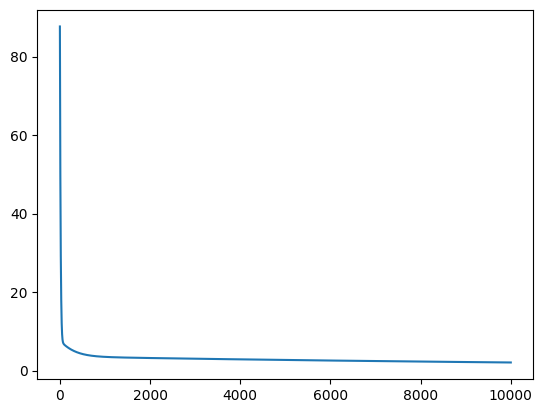

In [91]:
plt.plot(f1[0])

# Exercício 3: Método do gradiente acelerado

Construa uma função `accel_gd(J, df, w0, la=1, numb_iter=100)` que toma como entrada as funções `J()`, `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente com aceleração de Nesterov iniciando de `w0` e $t_0=1$:
\begin{align*}
w_{k+1}&:= y_k - la\nabla f(y_k),\\
t_{k+1} &:= \frac{1+\sqrt{1+4t_k^2}}{2},\\
y_{k+1} &:= w_{k+1} + \frac{t_{k}-1}{t_{k+1}}(w_{k+1}-w_{k}).
\end{align*}
Esta função deve retornar a sequência de valores da função `J(df(y))` em cada um dos iterados `y`, isto é, a sequência das normas dos gradientes de $y_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L`.

In [92]:
def accel_gd(J, df, w0, la=1, numb_iter=100):
    y = w0.copy()
    w = w0.copy()
    t = 1
    errors = []
    for _ in range(numb_iter):
        grad = df(y)
        w2 = y - la * grad
        t2 = (1 + np.sqrt(1 + 4 * t ** 2)) / 2
        y = w2 + ((t - 1) / t2) * (w2 - w)
        t = t2
        w = w2
        errors.append(J(grad))
    return  errors, y

In [93]:
# Nesterov accelerated gradient descent
f2 = accel_gd(J, Df, w0, la=1./L, numb_iter=it_max)


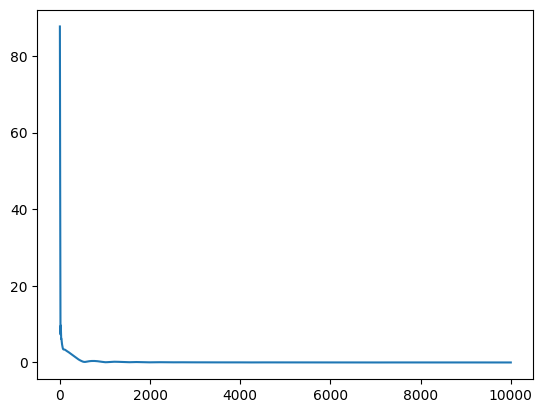

In [94]:

plt.plot(f2[0])

# Exercício 4: Método do gradiente acelerado com $\gamma$

Construa uma função `accel_gd_sc(J, df, w0, la=1, kappa, numb_iter=100)` que toma como entrada as funções `J()`, `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente com aceleração de Nesterov iniciando de `y0=w0`:
\begin{align*}
w_{k+1}&:= y_k - la\nabla f(y_k),\\
y_{k+1} &:= w_{k+1} + \frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}(w_{k+1}-w_{k}).
\end{align*}
Àcima, $\kappa:=L/\gamma$. Esta função deve retornar a sequência de valores da função `J(df(y))` em cada um dos iterados `y`, isto é, a sequência das normas dos gradientes de $y_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L`.

In [97]:
def accel_gd_sc(J, df, w0, kappa, la=1, numb_iter=100):
    y = w0.copy()
    w = w0.copy()
    errors = []
    for _ in range(numb_iter):
        grad = df(y)
        w2 = y - la * grad
        y2 = w2 + ((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)) * (w2 - w)
        w = w2
        y = y2
        errors.append(J(grad))
    return errors, y
    

In [98]:
# Nesterov accelerated gradient descent for strongly convex functions
f3 = accel_gd_sc(J, Df, w0, la=1./L, kappa=L/l2, numb_iter=it_max)


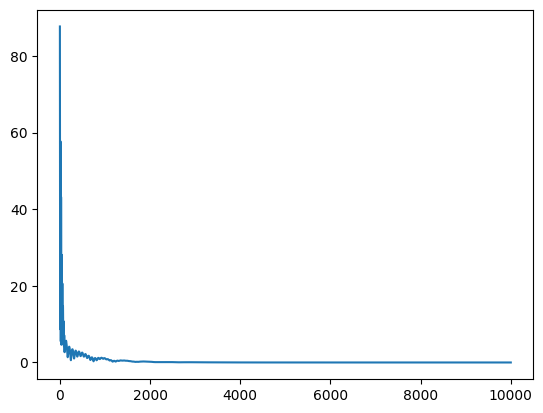

In [99]:

plt.plot(f3[0])

# Exercício 5: Adagrad-Norm

Construa uma função `ad_grad_norm(J, Df, w0, b0=0.5, eta=1, numb_iter=100)` que toma como entrada as funções `J()`, `Df`, o ponto inicial `w0`, parametros positivos `b0` e `eta` e o número de iterações `numb_iter` e implementa o método Adagrad-Norm iniciando de `w0`:
\begin{align*}
w_{k+1}&:= w_k - \frac{\eta}{\sqrt{b_0^2 + \sum_{j=1}^k\Vert\nabla f(w_j)\Vert_2^2}} \nabla f(w_k).
\end{align*}
Esta função deve retornar a sequência de valores da função `J(Df(w))` em cada um dos iterados `w`, isto é, a sequência das normas dos gradientes de $X_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com `b0=0.5` e `eta=1`.

In [100]:
def ad_grad_norm(J, Df, w0, b0=0.5, eta=1, numb_iter=100):
    w = w0.copy()
    errors = []
    grads_list = [J(Df(w)) ** 2]
    for _ in range(numb_iter):
        grad = Df(w)
        w2 = w - ((eta) / (b0 ** 2 + np.sum(grads_list))) * grad
        w = w2
        j = J(grad)
        grads_list.append(j ** 2)
        errors.append(j)
    return errors, w

In [101]:
# Adagrad-Norm
f4 = ad_grad_norm(J, Df, w0, b0=0.5, eta=1, numb_iter=it_max)


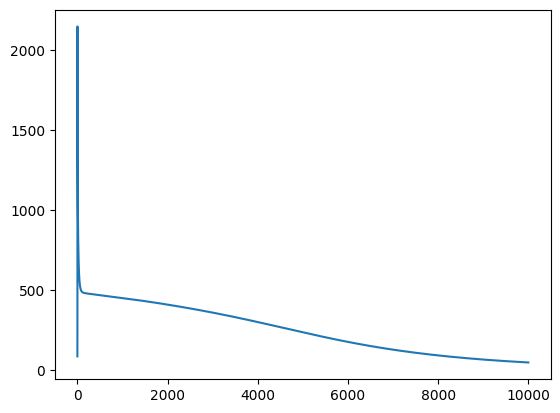

In [102]:

plt.plot(f4[0])

# Exercício 6: Adam

Construa uma função `adam(Df, w0, alpha, beta1, beta2, epsilon, numb_iter)` que toma como entrada as funções `Df`, o ponto inicial `w0`, parametros positivos `alpha`, `beta1`, `beta2`, `epsilon` e o número de iterações `numb_iter` e implementa o método Adam iniciando de `w0`, $m_0=0$, $v_0=0$ e $k=0$: para cada $j$ézima coordenada:
\begin{align*}
m_{k+1}[j] &:= \beta_1\cdot m_{k}[j] + (1-\beta_1)\cdot\nabla f(w_k)[j],\\
v_{k+1}[j] &:= \beta_2\cdot v_{k}[j] + (1-\beta_2)\cdot(\nabla f(w_k)[j])^2,\\
\hat m_{k+1}[j] &:= \frac{1}{1-\beta_1^{k+1}}m_{k+1}[j],\\
\hat v_{k+1}[j] &:= \frac{1}{1-\beta_2^{k+1}}v_{k+1}[j],\\
w_{k+1}[j] &:= w_{k}[j] - \frac{\alpha}{\sqrt{\hat v_{k+1}[j]} + \epsilon }\hat m_{k+1}[j].
\end{align*}
Esta função deve retornar a sequência de valores da função `J(Df(w))` em cada um dos iterados `w`, isto é, a sequência das normas dos gradientes de $w_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com `alpha=0.001`, `beta1=0.9`, `beta2=0.999`, `epsilon=10**(-8)`. 

In [103]:
def adam(Df, w0, alpha, beta1, beta2, epsilon, numb_iter):
    w = w0.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    errors = [J(Df(w))]
    
    for k in range(numb_iter):
        grad = Df(w)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        m_hat = m / (1 - beta1 ** (k + 1))
        v_hat = v / (1 - beta2 ** (k + 1))
        w = w - (alpha / (np.sqrt(v_hat) + epsilon)) * m_hat
        errors.append(J(grad))
        
    return errors, w


In [104]:
# Adam
f5 = adam(Df, w0, alpha=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, numb_iter=it_max)


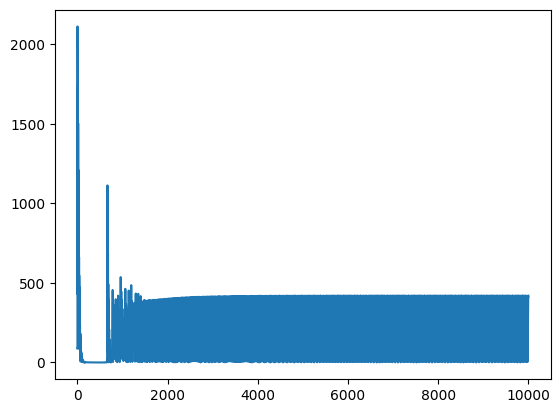

In [105]:

plt.plot(f5[0])

# Exercício 7: 

Implemente num mesmo gráfico os erros $\Vert\nabla f(w_k)\Vert$ de cada método em função no número de iterações.

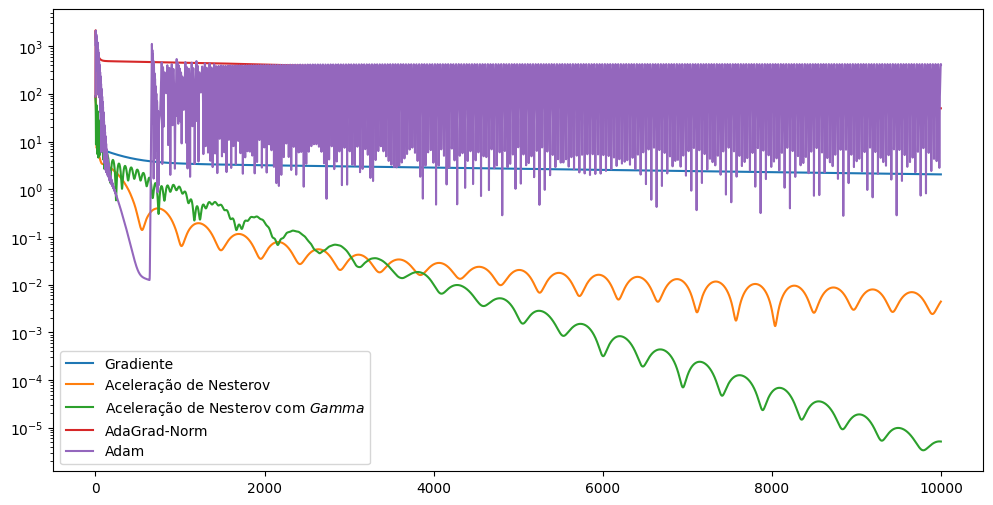

In [106]:
#Escreva código aquiplt.plot(f1[0], label="Método Gradiente")
plt.figure(figsize=(12,6))
plt.plot(f1[0], label="Gradiente")
plt.plot(f2[0], label="Aceleração de Nesterov")
plt.plot(f3[0], label="Aceleração de Nesterov com $Gamma$")
plt.plot(f4[0], label="AdaGrad-Norm")
plt.plot(f5[0], label="Adam")

plt.yscale('log')
plt.legend()
plt.show()

# Exercício 8:

Experimente com os hyper-parâmetros de Adagrad-Norm and Adam para ver se eles podem chegar perto ou superar a performance de GD e Nesterov. Plote o gráfico como no Exercício 7. 

In [ ]:
from itertools import product
import time
param_grid_ad_grad = {
    'b0': [10.0],
    'eta': [1,0.1,0.01]
}

results_ad_grad = []

param_keys_ad = param_grid_ad_grad.keys()
param_values_ad = param_grid_ad_grad.values()
param_combinations_ad = [dict(zip(param_keys_ad, v)) for v in product(*param_values_ad)]

print(f"Testando {len(param_combinations_ad)} combinações para ad_grad_norm...")

start_time_ad = time.time()
for params in param_combinations_ad:
    errors_history, w_final = ad_grad_norm(J, Df, w0, numb_iter=it_max, **params)
    
    final_metric = J(Df(w_final))
    
    results_ad_grad.append((final_metric, params))

best_metric_ad, best_params_ad = min(results_ad_grad, key=lambda item: item[0])

print(f"--- Resultado para ad_grad_norm (em {time.time() - start_time_ad:.2f}s) ---")
print(f"  Melhor Métrica (Norma Grad): {best_metric_ad:.6f}")
print(f"  Melhores Parâmetros: {best_params_ad}")


print("\n--- Iniciando Grid Search para adam ---")

param_grid_adam = {
    'alpha': [0.0001, 0.001, 0.00001],
    'beta1': [0.9],         
    'beta2': [0.999],       
    'epsilon': [1e-8]       
}

results_adam = []

param_keys_adam = param_grid_adam.keys()
param_values_adam = param_grid_adam.values()
param_combinations_adam = [dict(zip(param_keys_adam, v)) for v in product(*param_values_adam)]

print(f"Testando {len(param_combinations_adam)} combinações para adam...")

start_time_adam = time.time()
for params in param_combinations_adam:
    errors_history, w_final = adam(Df, w0, numb_iter=it_max, **params)
    
    final_metric = J(Df(w_final))
    
    results_adam.append((final_metric, params))
    
best_metric_adam, best_params_adam = min(results_adam, key=lambda item: item[0])

print(f"--- Resultado para adam (em {time.time() - start_time_adam:.2f}s) ---")
print(f"  Melhor Métrica (Norma Grad): {best_metric_adam:.6f}")
print(f"  Melhores Parâmetros: {best_params_adam}")

Testando 3 combinações para ad_grad_norm...
--- Resultado para ad_grad_norm (em 888.37s) ---
  Melhor Métrica (Norma Grad): 2.647214
  Melhores Parâmetros: {'b0': 10.0, 'eta': 0.01}

--- Iniciando Grid Search para adam ---
Testando 3 combinações para adam...
--- Resultado para adam (em 883.43s) ---
  Melhor Métrica (Norma Grad): 0.000071
  Melhores Parâmetros: {'alpha': 0.0001, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08}


In [108]:
f4 = ad_grad_norm(J, Df, w0,numb_iter=it_max, **best_params_ad)

In [109]:
f5 = adam(Df, w0, numb_iter=it_max, **best_params_adam)

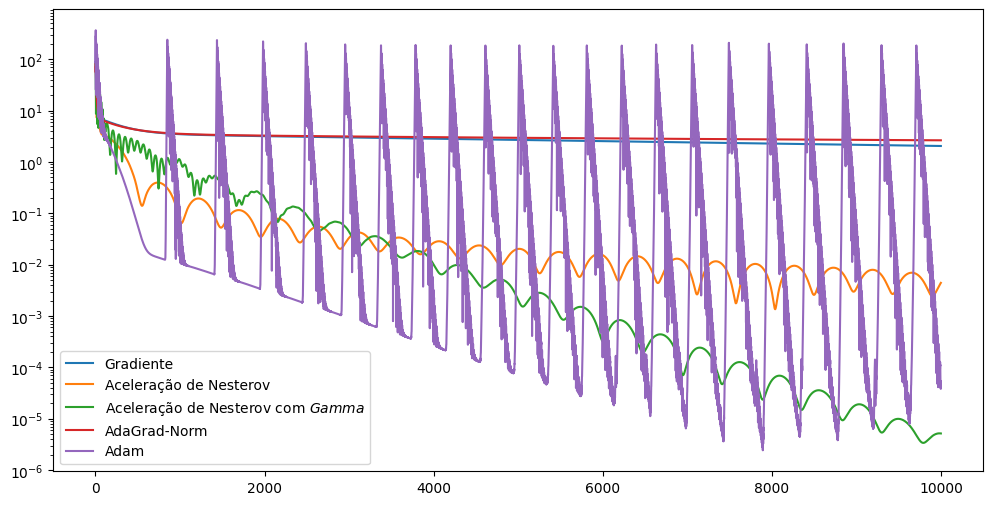

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(f1[0], label="Gradiente")
plt.plot(f2[0], label="Aceleração de Nesterov")
plt.plot(f3[0], label="Aceleração de Nesterov com $Gamma$")
plt.plot(f4[0], label="AdaGrad-Norm")
plt.plot(f5[0], label="Adam")

plt.yscale('log')
plt.legend()
plt.show()